# Notebook 03: Market concentration and corporate power

**Research context:** *Rethinking Vacations in an Era of Immobility*  
Data sources: Port Economics, Management and Policy (2026); CLIA 2025 State of the Cruise Industry; Tips For Travellers; Wikipedia corporate data.

This notebook visualizes the oligopolistic structure of the cruise industry: four corporations control nearly 79% of global capacity. This data supports Bianchi & Milano's (2024) analysis of how 'polycrisis' and tourism capitalism are structurally linked — crises do not disrupt the industry but are metabolized and resolved through further concentration of capital.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from pathlib import Path

DATA = Path('../data')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

BLUE = '#185FA5'
RED = '#E24B4A'
AMBER = '#BA7517'
GREEN = '#3B6D11'
DARK_RED = '#993C1D'
GRAY = '#888780'
GRAY_LIGHT = '#D3D1C7'
TEXT = '#2C2C2A'
TEXT_SEC = '#5F5E5A'
BG = '#FAFAF8'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid': False,
    'figure.facecolor': BG,
    'axes.facecolor': BG,
})
print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv(DATA / 'market_concentration.csv')
print(df[['company', 'market_share_pct', 'ships']].to_string())

                          company  market_share_pct ships
0            Carnival Corporation              50.0  100+
1           Royal Caribbean Group              25.0    65
2                     MSC Cruises               7.2    22
3  Norwegian Cruise Line Holdings               8.7    30
4                      All others               9.1  100+


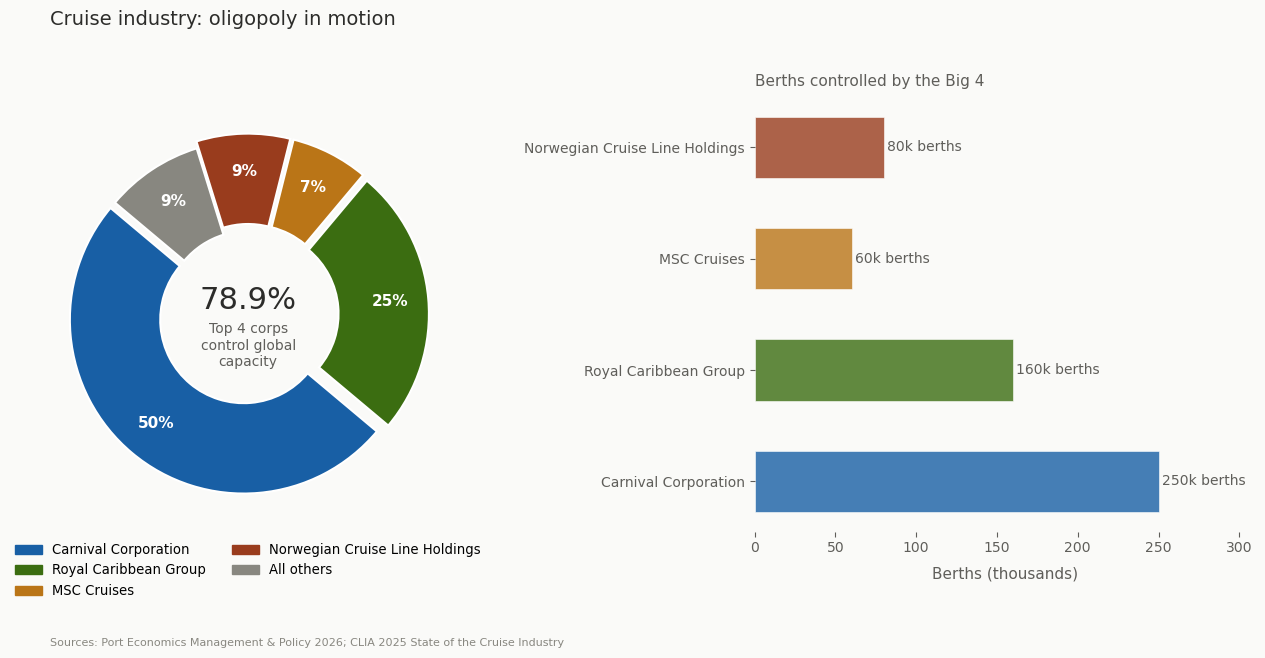

Saved: figures/fig_market_concentration.png


In [3]:
# --- Fig 3: Donut chart (matplotlib) ---
colors = [BLUE, GREEN, AMBER, DARK_RED, GRAY]
explode = (0.04, 0.04, 0.04, 0.04, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Donut
wedges, texts, autotexts = ax1.pie(
    df.market_share_pct,
    labels=None,
    colors=colors,
    autopct='%1.0f%%',
    pctdistance=0.78,
    startangle=140,
    explode=explode,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_color('white')
    t.set_fontweight('bold')

# Center annotation
ax1.text(0, 0.08, '78.9%', ha='center', va='center',
         fontsize=22, fontweight='500', color=TEXT)
ax1.text(0, -0.18, 'Top 4 corps\ncontrol global\ncapacity',
         ha='center', va='center', fontsize=10, color=TEXT_SEC)

legend_items = [mpatches.Patch(color=c, label=row.company)
                for c, (_, row) in zip(colors, df.iterrows())]
ax1.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5, -0.18),
           frameon=False, fontsize=9.5, ncol=2)

# Bar chart: ships by corporation
df_big4 = df[df.company != 'All others'].copy()
bar_colors = [BLUE, GREEN, AMBER, DARK_RED]
bars = ax2.barh(df_big4.company, df_big4.berths_thousands,
                color=bar_colors, alpha=0.8,
                edgecolor='white', linewidth=0.5, height=0.55)

for bar, val in zip(bars, df_big4.berths_thousands):
    ax2.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val}k berths', va='center', fontsize=10, color=TEXT_SEC)

ax2.set_xlabel('Berths (thousands)', color=TEXT_SEC, labelpad=8)
ax2.tick_params(colors=TEXT_SEC, labelsize=10)
ax2.set_xlim(0, 310)
ax2.spines['bottom'].set_color(GRAY_LIGHT)
ax2.set_title('Berths controlled by the Big 4', loc='left',
              fontsize=11, color=TEXT_SEC, pad=8)

fig.suptitle('Cruise industry: oligopoly in motion',
             x=0.06, y=1.02, ha='left', fontsize=14,
             fontweight='500', color=TEXT)
fig.text(0.06, -0.04,
         'Sources: Port Economics Management & Policy 2026; CLIA 2025 State of the Cruise Industry',
         fontsize=8, color=GRAY, ha='left')

plt.tight_layout()
fig.savefig(FIGURES / 'fig_market_concentration.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: figures/fig_market_concentration.png')

In [4]:
# --- Plotly interactive donut ---
fig_p = go.Figure(go.Pie(
    labels=df.company,
    values=df.market_share_pct,
    hole=0.55,
    marker_colors=colors,
    marker_line_color='white',
    marker_line_width=2,
    pull=[0.04]*4 + [0],
    textinfo='label+percent',
    textposition='outside',
    hovertemplate=('<b>%{label}</b><br>'
                   'Market share: %{value}%<br>'
                   'Passengers per year: approx. %{customdata}M<extra></extra>'),
    customdata=(df.market_share_pct * 0.346).round(1)  # 34.6M total 2024
))

fig_p.add_annotation(
    text='<b>78.9%</b><br>Big 4 control',
    x=0.5, y=0.5, showarrow=False,
    font=dict(size=15, color=TEXT)
)

fig_p.update_layout(
    title='Global cruise market share by parent corporation (2024)',
    showlegend=True,
    plot_bgcolor=BG, paper_bgcolor=BG, font_color=TEXT,
    margin=dict(t=70, b=40, l=40, r=40),
    legend=dict(orientation='h', yanchor='bottom', y=-0.15, xanchor='center', x=0.5)
)

fig_p.write_html(FIGURES / 'fig_market.html')
fig_p.show()
print('Saved: figures/fig_market.html')

Saved: figures/fig_market.html
